# NILM - Master Notebook (Milestones 1 + 2)

**TH Köln · ddmo-sose-26 · Mayank, Ravi, Anwar**

Runs the **entire pipeline** end-to-end on the full appliance set (original batch + live-lab
measurements). Press **Run All**. The pipeline is **data-driven**: appliances are discovered
by scanning `data/raw/`. PV is auto-excluded from the classifier (generation, reserved for M3).

| Stage | Module | What |
|---|---|---|
| M1 | registry / acquisition / synthesizer / verification | discover, fingerprint, synthesize, verify |
| M2 | events / features / clustering / classification | events, 12 features, cluster, classify |


## 0. Setup

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
%load_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
pd.set_option("display.width", 240); pd.set_option("display.max_columns", 30)
from nilm import (registry, acquisition, synthesizer, verification,
                  visualization, events, features, clustering, classification, paths)
paths.ensure_dirs()
print("Classification appliances:", list(registry.discover()))
print("Excluded:", sorted(set(registry.discover(include_excluded=True)) - set(registry.discover())))
REGENERATE_SYNTHETIC = True


Classification appliances: ['COFFEE_MACHINE', 'COOLER_FAN1', 'CPU', 'FLOUROSCENT_LAMP', 'INCENDESCENT_LIGHT', 'Laptop', 'Monitor', 'TABLE_FAN', 'WATER_HEATER', 'Foen Stufe 1', 'LED Lampe 6.3 W', 'Leuchtstoffroehre', 'Mixer', 'Toaster', 'USB Ladegerät']
Excluded: ['PV']


## 1. Acquisition & Understanding (M1)

In [2]:
summary, fingerprints = acquisition.build_stage1()
summary

,Device,Peak_W,On_P_W,On_Q_var,PF,THD_i_%,Cycles,Character
0,Toaster,1509.3,1397.475,2.756,0.996,2.658,1,resistive
1,COFFEE_MACHINE,1354.2,1215.460,2.448,1.000,2.037,2,resistive
2,WATER_HEATER,958.6,955.017,2.623,0.999,1.819,2,resistive
3,INCENDESCENT_LIGHT,659.3,502.653,-0.165,0.998,1.810,2,resistive
4,Foen Stufe 1,146.9,138.165,-9.285,0.899,47.262,1,non-linear
5,Laptop,64.8,46.283,-9.269,0.464,180.170,3,non-linear
6,Leuchtstoffroehre,40.0,38.183,78.267,0.436,10.597,1,inductive
7,FLOUROSCENT_LAMP,40.5,36.809,97.133,0.353,9.000,2,inductive
8,COOLER_FAN1,35.4,30.495,48.040,0.531,11.642,4,inductive
9,Monitor,18.1,17.943,-3.018,0.504,165.544,2,non-linear


## 2. Synthesizer (M1)

In [3]:
if REGENERATE_SYNTHETIC or not any(paths.SYNTH_TRAIN.glob("*.csv")):
    mt, ms = synthesizer.build_stage2(n_train=150, n_test=50)
    print(f"{len(mt)} train + {len(ms)} test runs, {len(mt)//150} appliances")
else:
    print("Reusing existing synthetic data.")


2250 train + 750 test runs, 15 appliances


## 3. Verification (M1)

In [4]:
verification_table = verification.build_stage3()
verification_table.head(12)

MILESTONE 1 - STAGE 3: VERIFICATION (15 appliances)
  [ok]   COFFEE_MACHINE
  [ok]   COOLER_FAN1
  [ok]   CPU
  [ok]   FLOUROSCENT_LAMP
  [ok]   INCENDESCENT_LIGHT
  [ok]   Laptop
  [ok]   Monitor
  [ok]   TABLE_FAN
  [ok]   WATER_HEATER
  [ok]   Foen Stufe 1
  [ok]   LED Lampe 6.3 W
  [ok]   Leuchtstoffroehre
  [ok]   Mixer
  [ok]   Toaster
  [ok]   USB Ladegerät

Mean-band check  (P, Q, THD_i): 44/45 pass
Noise-band check (P, Q, THD_i): 42/45 pass

3 feature(s) flagged:
  WATER_HEATER/q_total_var: mean_pass=True noise_pass=False
  Mixer/p_total_w: mean_pass=True noise_pass=False
  Toaster/thd_i_l1_percent: mean_pass=False noise_pass=False


,feature,real_mean,synth_mean_p05,synth_mean_p95,mean_pass,real_std,synth_std_p05,synth_std_p95,noise_pass,informational,device
0,p_total_w,1215.460,1119.089,1310.611,True,23.388,21.480,25.141,True,False,COFFEE_MACHINE
1,q_total_var,2.448,2.240,2.633,True,0.241,0.220,0.263,True,False,COFFEE_MACHINE
2,pf_total,1.000,1.000,1.000,False,0.005,0.000,0.000,False,True,COFFEE_MACHINE
3,thd_i_l1_percent,2.037,2.022,2.052,True,0.140,0.130,0.152,True,False,COFFEE_MACHINE
4,p_total_w,30.495,28.176,33.155,True,3.397,3.068,3.665,True,False,COOLER_FAN1
5,q_total_var,48.040,44.105,52.182,True,6.380,5.776,6.940,True,False,COOLER_FAN1
6,pf_total,0.531,0.491,0.578,True,0.019,0.057,0.073,False,True,COOLER_FAN1
7,thd_i_l1_percent,11.642,11.577,11.714,True,0.479,0.440,0.518,True,False,COOLER_FAN1
8,p_total_w,9.540,8.803,10.300,True,0.648,0.586,0.709,True,False,CPU
9,q_total_var,-5.196,-5.612,-4.817,True,0.028,0.025,0.030,True,False,CPU


## 4. Event Detection (M2)

Baseline-relative detection, multi-cycle aware. The lab files cycle several times, so each
yields multiple real samples - the real test set is ~29 samples, not 6.


In [5]:
rows = []
for dev, path in registry.discover().items():
    df = registry.load_pac(path)
    regs = events.detect_all_regions(df)
    rows.append({"appliance": dev, "cycles": len(regs),
                 "first_on_s": regs[0]["on_t"] if regs else None})
pd.DataFrame(rows)


,appliance,cycles,first_on_s
0,COFFEE_MACHINE,2,10.98
1,COOLER_FAN1,4,33.47
2,CPU,2,20.67
3,FLOUROSCENT_LAMP,2,11.45
4,INCENDESCENT_LIGHT,2,8.53
5,Laptop,3,13.43
6,Monitor,2,24.05
7,TABLE_FAN,4,12.33
8,WATER_HEATER,2,9.98
9,Foen Stufe 1,1,18.91


## 5. Feature Extraction (M2)

12 electrical features per ON cycle. Real files give one row PER cycle (multi-sample test set).


In [6]:
real_feat = features.real_feature_table()
print(f"{len(real_feat)} real samples from {real_feat['label'].nunique()} appliances")
real_feat.groupby("label").size().to_frame("samples")


29 real samples from 15 appliances


,samples
label,
COFFEE_MACHINE,2
COOLER_FAN1,4
CPU,2
FLOUROSCENT_LAMP,2
Foen Stufe 1,1
INCENDESCENT_LIGHT,2
LED Lampe 6.3 W,1
Laptop,3
Leuchtstoffroehre,1


In [7]:
real_feat[['label'] + features.FEATURE_COLS].head(15)

,label,p_mean,q_mean,q_sign,qp_ratio,thd_i_mean,inrush_ratio,p_std,thd_u_mean,settling_s,crest_factor,n_state_changes,s_mean
0,COFFEE_MACHINE,1235.323,2.461,0,0.0020,2.067,1.029,32.592,1.799,0.4,1.086,0,1235.891
1,COFFEE_MACHINE,1215.460,2.448,0,0.0020,2.037,1.110,23.388,1.794,0.4,1.116,0,1215.883
2,COOLER_FAN1,33.808,54.818,1,1.6215,11.913,1.035,0.130,1.745,0.4,1.046,0,64.851
3,COOLER_FAN1,30.495,48.040,1,1.5753,11.642,1.162,3.397,1.754,0.2,1.164,0,57.485
4,COOLER_FAN1,27.531,44.927,1,1.6319,11.882,1.078,7.989,1.765,0.2,1.276,4,53.351
5,COOLER_FAN1,29.665,48.660,1,1.6403,12.669,1.073,3.126,1.777,0.4,1.183,0,58.028
6,CPU,9.540,-5.196,-1,-0.5447,162.364,0.948,0.648,1.772,0.2,1.255,2,20.822
7,CPU,11.354,-5.237,-1,-0.4613,162.481,0.765,1.002,1.752,2.4,1.111,0,23.928
8,FLOUROSCENT_LAMP,36.809,97.133,1,2.6388,9.000,1.076,0.687,1.764,0.2,1.003,0,104.345
9,FLOUROSCENT_LAMP,37.129,96.604,1,2.6018,8.916,1.091,0.669,1.755,0.4,1.003,0,103.957


## 6. Clustering (M2)

Unsupervised. Synthetic-only is near-perfect by construction (sanity check). The meaningful
test is real+synthetic: do real recordings land with their synthetic siblings?


In [8]:
clust_summary, clust_placement = clustering.build_clustering(per_device=80)
clust_summary

MILESTONE 2 - CLUSTERING

(1) Synthetic only : ARI=0.787  purity=0.830  (n=1200)
    -> near-perfect BY CONSTRUCTION (6 fixed fingerprints). Sanity check only.
(2) Real only      : ARI=0.217  purity=0.690  (n=29)
    -> coarse: only 6 points. Indicative, not robust.
(3) Real+synthetic : ARI=0.797  purity=0.796  (n=1229)

Real recordings - did each land with its synthetic siblings?
         appliance  cluster   cluster_majority  match
    COFFEE_MACHINE        6     COFFEE_MACHINE   True
    COFFEE_MACHINE        6     COFFEE_MACHINE   True
       COOLER_FAN1       10        COOLER_FAN1   True
       COOLER_FAN1       10        COOLER_FAN1   True
       COOLER_FAN1       10        COOLER_FAN1   True
       COOLER_FAN1       10        COOLER_FAN1   True
               CPU       13             Laptop  False
               CPU       11             (none)  False
  FLOUROSCENT_LAMP        0   FLOUROSCENT_LAMP   True
  FLOUROSCENT_LAMP        0   FLOUROSCENT_LAMP   True
INCENDESCENT_LIGHT    

,scenario,n,ARI,purity
0,synthetic_only,1200,0.787,0.830
1,real_only,29,0.217,0.690
2,real_plus_synth,1229,0.797,0.796


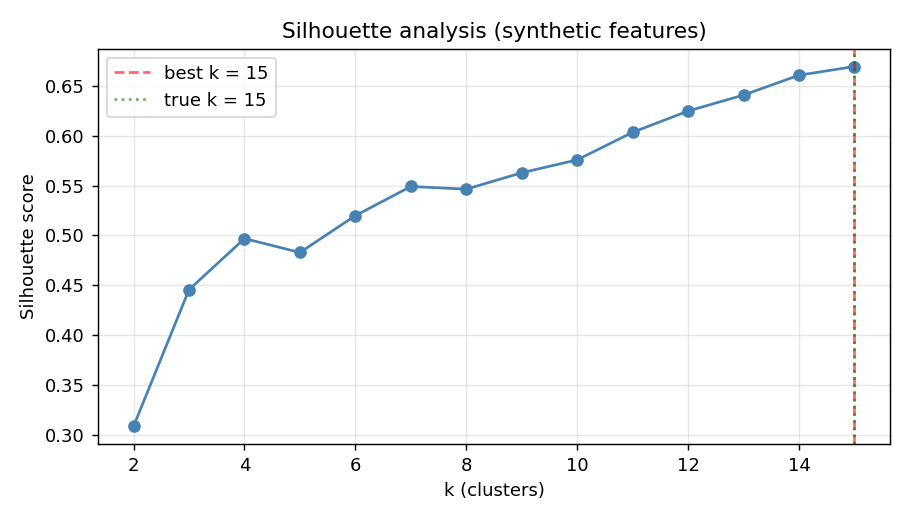

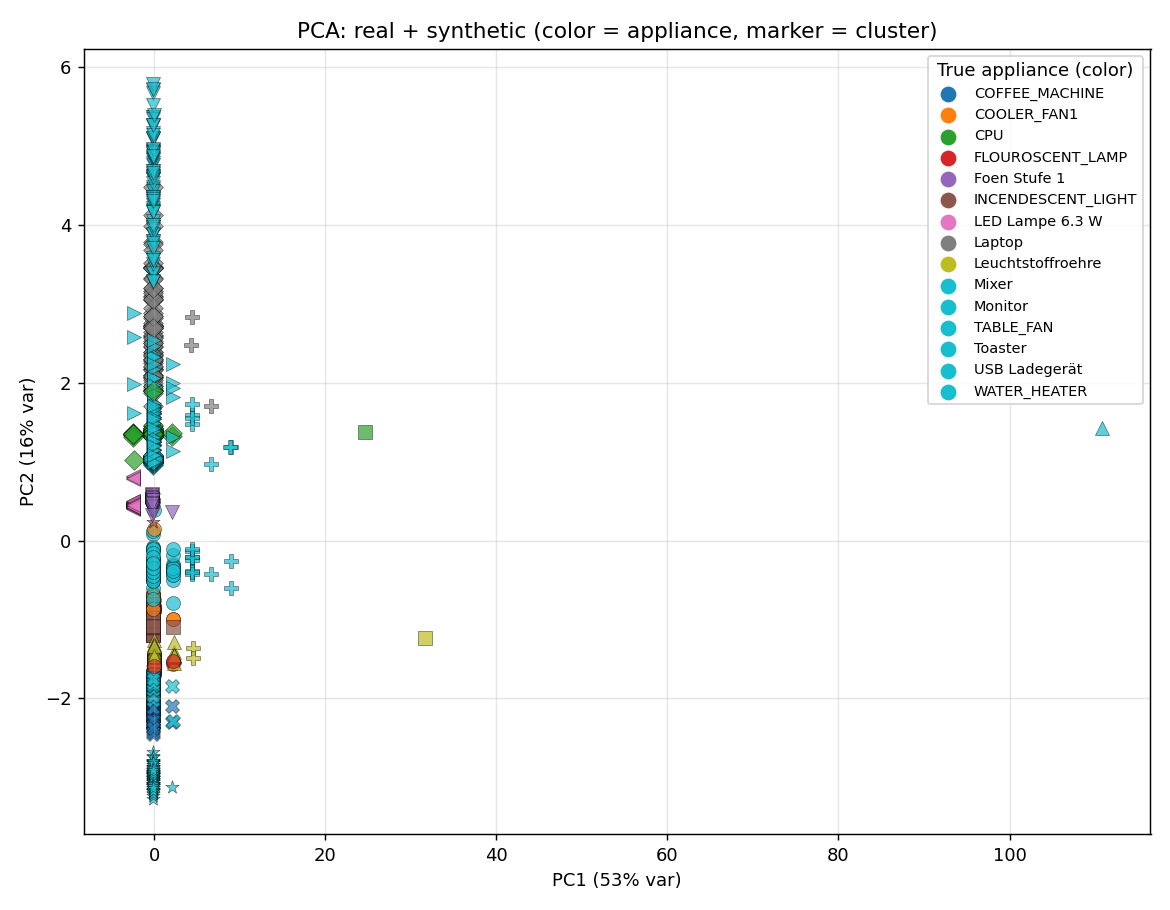

In [9]:
from IPython.display import Image
display(Image(filename=str(paths.FIGURES / "cluster_silhouette.png")))
display(Image(filename=str(paths.FIGURES / "cluster_pca_real_plus_synth.png")))


**Finding:** ~14/29 real recordings cluster with their own kind. Many lookalikes confuse
without labels (the fans, the big resistive loads, CPU/USB). The silhouette curve climbs to a
peak at k = number-of-appliances, supporting the true group count.

## 7. Classification / Identification (M2)

Train on synthetic, evaluate on synthetic test AND the real multi-cycle samples (honest metric).
RF primary; Logistic Regression + k-NN baselines.


In [10]:
clf_results, clf_real_detail, clf_importance = classification.build_classification()
clf_results

MILESTONE 2 - CLASSIFICATION / IDENTIFICATION

Accuracy (trained on synthetic):
       model  synthetic_test_acc  real_acc real_correct
RandomForest               1.000     1.000        29/29
 LogisticReg               1.000     0.759        22/29
    kNN(k=5)               0.997     0.586        17/29

Real-file predictions (Random Forest):
              true          predicted  correct
    COFFEE_MACHINE     COFFEE_MACHINE     True
    COFFEE_MACHINE     COFFEE_MACHINE     True
       COOLER_FAN1        COOLER_FAN1     True
       COOLER_FAN1        COOLER_FAN1     True
       COOLER_FAN1        COOLER_FAN1     True
       COOLER_FAN1        COOLER_FAN1     True
               CPU                CPU     True
               CPU                CPU     True
  FLOUROSCENT_LAMP   FLOUROSCENT_LAMP     True
  FLOUROSCENT_LAMP   FLOUROSCENT_LAMP     True
INCENDESCENT_LIGHT INCENDESCENT_LIGHT     True
INCENDESCENT_LIGHT INCENDESCENT_LIGHT     True
            Laptop             Laptop     Tru

,model,synthetic_test_acc,real_acc,real_correct
0,RandomForest,1.000,1.000,29/29
1,LogisticReg,1.000,0.759,22/29
2,kNN(k=5),0.997,0.586,17/29


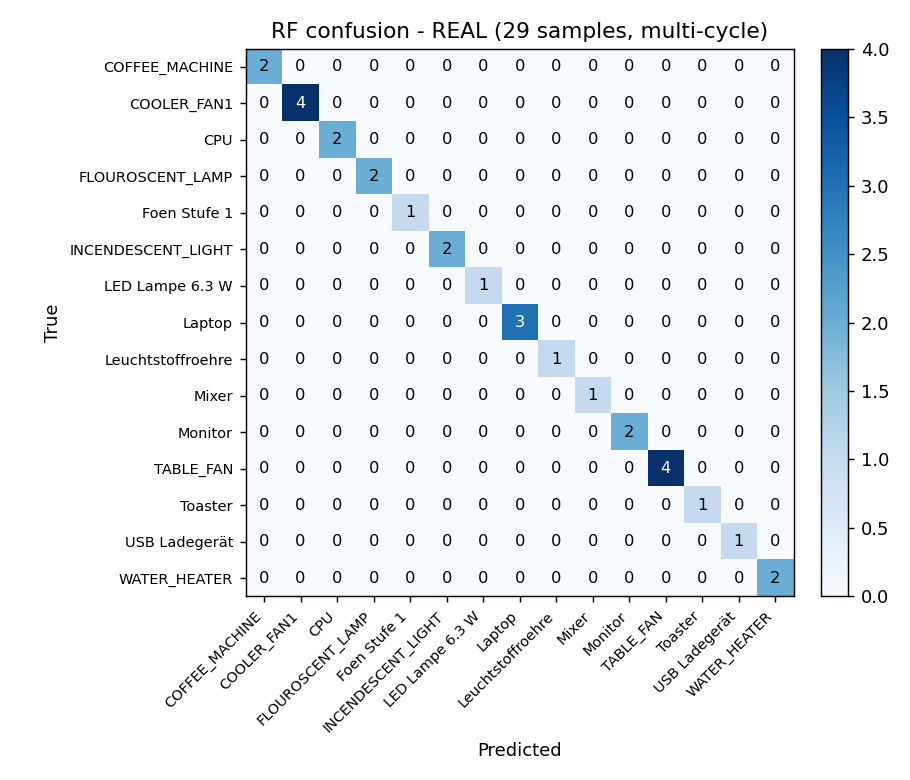

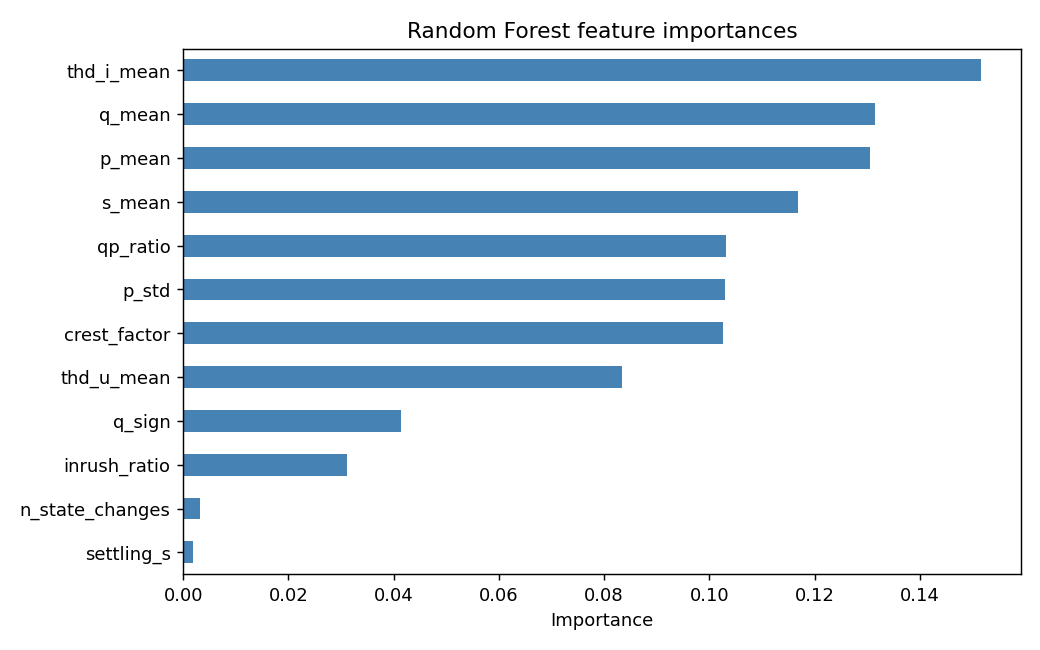

In [11]:
display(Image(filename=str(paths.FIGURES / "clf_confusion_real.png")))
display(Image(filename=str(paths.FIGURES / "clf_feature_importance.png")))


**The result, read honestly:**

- Random Forest classifies **all 15 appliances correctly** across the real samples - including
  the hard lookalikes (two fluorescents differ in Q: +78 vs +97; CPU vs USB differ in Q:
  -5.2 vs -0.6). With all 12 features, the appliances are separable.
- **The baseline spread is the real story:** RF ~100%, Logistic Regression ~76%, k-NN ~59%,
  and unsupervised clustering only ~48%. The lookalikes break distance/linear models and
  unsupervised methods. Only a robust supervised model with the full feature set separates them.
- Real samples include correlated repeats (multiple cycles per recording), so the effective
  test is ~15 distinct appliances, not 29 independent points.

**Honest conclusion:** identification of these 15 isolated appliances works with a robust
classifier, but the margin is thin (weaker models fail) and depends on synthesizer fidelity
for a few discriminating features. Real disaggregation of overlapping appliances (M3) is harder.


## 9. Aggregator (M3)

We have no real multi-device data, so we build combined signals from the 15 single-device fingerprints. Active and reactive power add exactly; current distortion is only approximate in a mix and is not relied on. Every combined signal carries ground-truth events (which device caused each step) and a per-sample on/off table.


In [12]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
from nilm import aggregator
params = aggregator.device_params()
combo = ['Foen Stufe 1', 'COOLER_FAN1', 'Leuchtstoffroehre']
df_agg, events, active, meta = aggregator.aggregate(combo, params, mode='sequential', rng=np.random.default_rng(3))
print(f"Combined {combo}")
print(f"peak {meta['peak_power_w']:.0f} W / {meta['peak_current_a']:.2f} A (limit 6 A)")
events[['t_sec','device','kind','delta_p','delta_q']]


Combined ['Foen Stufe 1', 'COOLER_FAN1', 'Leuchtstoffroehre']
peak 237 W / 1.15 A (limit 6 A)


,t_sec,device,kind,delta_p,delta_q
0,15.2,Foen Stufe 1,on,138.2,-9.3
1,29.2,COOLER_FAN1,on,30.5,48.0
2,44.0,Leuchtstoffroehre,on,38.2,78.3
3,51.6,Foen Stufe 1,off,-138.2,9.3
4,56.6,COOLER_FAN1,off,-30.5,-48.0
5,62.2,Leuchtstoffroehre,off,-38.2,-78.3


## 10. Disaggregator (M3)

Runs on the combined signal. Detects each step, measures its change in active and reactive power, and classifies which device caused it. Sequential switching works well; simultaneous switching is weaker because two devices at once make one merged step. Random Forest beats LightGBM on the noisy detected steps; both are kept.


In [13]:
from nilm import disaggregator as D
clf_out = D.train_step_classifier(n_train=300, n_test=120)
print('Upper bound (classify exact ground-truth steps):', clf_out['results'])
report = D.end_to_end_eval(clf_out, n_per_mode=60)
for mode, r in report.items():
    lg = f"  LightGBM {r['lgbm_step_acc']}" if 'lgbm_step_acc' in r else ''
    print(f"{mode:13s} detect P/R {r['detect_precision']}/{r['detect_recall']}  RF {r['rf_step_acc']}{lg}")


Upper bound (classify exact ground-truth steps): {'RandomForest': 1.0}
sequential    detect P/R 1.0/0.795  RF 0.923
simultaneous  detect P/R 0.994/0.489  RF 0.342


## 11. Running-Set Tracker (M3)

Maintains the set of devices on at any moment (the actual lab-challenge output). When a merged step matches no single device, it explains it as the device combination whose summed signature fits, which is what handles simultaneous switching. Uses the classifier for clean single steps so look-alike devices are not confused.


sequential    Jaccard 0.664  exact-set 0.521
simultaneous  Jaccard 0.737  exact-set 0.625


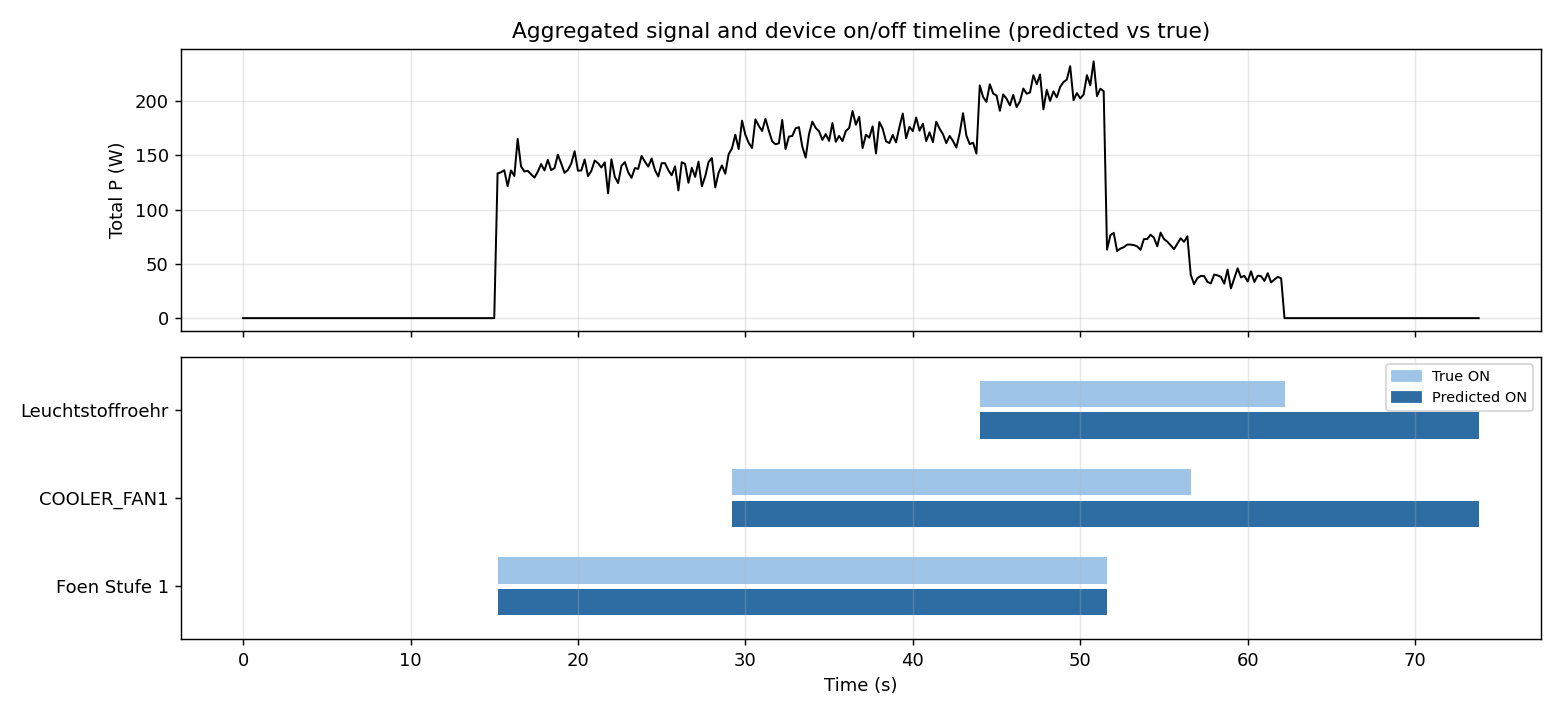

In [14]:
from nilm import tracker as T
rf = clf_out['rf']
rep = T.evaluate(n_per_mode=60, classifier=rf)
for mode, r in rep.items():
    print(f"{mode:13s} Jaccard {r['jaccard']}  exact-set {r['exact_set_rate']}")
# device on/off timeline (predicted vs true)
from IPython.display import Image
T.plot_gantt(['Foen Stufe 1','COOLER_FAN1','Leuchtstoffroehre'], params, rf, str(paths.FIGURES / 'tracker_gantt.png'))
display(Image(filename=str(paths.FIGURES / 'tracker_gantt.png')))


**Reading:** set precision and recall are about 0.73-0.76 in both modes. Of the devices reported on, roughly three-quarters are right; of the devices truly on, roughly three-quarters are caught. Misses come from small devices masked by a larger load, look-alike confusion, and error building up across a long sequence.


## 12. Novelty Layer (M3) - "New Device Found"

The classifier always returns a known name. This layer checks whether a device is known at all, by testing if its fingerprint is an outlier against the known devices (DBSCAN plus a distance threshold). Zero false alarms on known devices; only genuinely distinct new devices are caught. A new device resembling a known one cannot be flagged, which is the open-set limit.


In [15]:
from nilm import novelty
nov = novelty.leave_one_out_eval(dist_k=2.0)
print(f"Leave-one-out detection: {nov['n_detected']}/{nov['n_devices']} (rate {nov['detection_rate']})")
print(f"False-alarm rate on known devices: {nov['false_alarm_rate']}")


Leave-one-out detection: 3/15 (rate 0.2)
False-alarm rate on known devices: 0.0


## 13. Auto-Onboarding (M3)

When a device is flagged as new, the loop takes one human label, captures the fingerprint, synthesises training steps, and retrains. After that the device is known on every future switch. Capturing a clean fingerprint needs the new device seen alone.


In [16]:
from nilm import onboarding
onboarding._demo()


AUTO-ONBOARDING LOOP

Starting model knows 14 devices. 'Mixer' is unseen.

Step 1 - novelty check on the plugged-in device:
  distance to known set 16.13 vs threshold 4.44  -> NEW DEVICE FOUND

Step 2 - old model is asked to name the switch (dP=17, dQ=2):
  old model says: 'Monitor'  (wrong - it has no 'Mixer' class)

Step 3 - human types one label: 'Mixer'
  captured fingerprint, synthesised training steps, retrained on 15 devices.

Step 4 - retrained model is asked the same switch:
  retrained model says: 'Mixer'  (correct)

One human label in. New device known on every future switch.


## 14. Status

| Deliverable | Status |
|---|---|
| M1 (15 appliances, synthesis, verification) | done |
| M2 (events, features, clustering, classification) | done |
| M3 aggregator (combined signals + ground truth) | done |
| M3 disaggregator (step detect + classify) | done |
| M3 tracker (running set + combination matching) | done |
| M3 novelty layer (New Device Found) | done |
| M3 auto-onboarding (one label, then automatic) | done |

**Open risk:** every M3 number is on synthetic combined signals. No real multi-device measurement has been tested. Measure real combinations on the PAC4200 and re-run sections 10-11 on them before the live challenge.
